# Modelos con validación cruzada

Se vuelven a comparar los cinco modelos utilizando validación cruzada estratificada de cinco particiones. Todo el proceso se realiza únicamente con el conjunto de entrenamiento.

## Importaciones

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    make_scorer,
    multilabel_confusion_matrix,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


## Lectura del conjunto de entrenamiento

In [2]:
def localizar_raiz_proyecto():
    """Localiza la carpeta principal del repositorio."""
    carpeta_actual = Path.cwd().resolve()

    if (carpeta_actual / "datos").exists():
        return carpeta_actual

    if (carpeta_actual.parent / "datos").exists():
        return carpeta_actual.parent

    raise FileNotFoundError(
        "No se encuentra la carpeta 'datos'. Abre el notebook desde el repositorio."
    )


RAIZ_PROYECTO = localizar_raiz_proyecto()
RUTA_TRAIN = RAIZ_PROYECTO / "datos" / "procesados" / "train.csv"


In [3]:
df_train = pd.read_csv(RUTA_TRAIN)

X_train = df_train.drop(columns=["clase"])
y_train = df_train["clase"]

clases = ["otro", "hipotiroidismo", "hipertiroidismo"]

print("Dimensiones de X_train:", X_train.shape)
print("Dimensiones de y_train:", y_train.shape)
display(y_train.value_counts().to_frame())


Dimensiones de X_train: (7337, 26)
Dimensiones de y_train: (7337,)


,count
clase,
otro,6628
hipotiroidismo,527
hipertiroidismo,182


El conjunto de prueba no se utiliza en este notebook. Cada modelo se entrena y valida exclusivamente con distintas particiones del conjunto de entrenamiento.

## Preprocesamiento

In [4]:
variables_numericas = [
    "edad", "TSH", "T3", "TT4", "T4U", "FTI"
]

variables_binarias = [
    "sexo",
    "tratamiento_con_tiroxina",
    "consulta_sobre_tiroxina",
    "medicacion_antitiroidea",
    "enfermo",
    "embarazada",
    "cirugia_tiroidea",
    "tratamiento_I131",
    "consulta_hipotiroidismo",
    "consulta_hipertiroidismo",
    "litio",
    "bocio",
    "tumor",
    "hipopituitarismo",
    "trastorno_psiquiatrico",
    "TSH_medida",
    "T3_medida",
    "TT4_medida",
    "T4U_medida",
    "FTI_medido",
]


In [5]:
procesador_numerico = Pipeline([
    ("imputacion", SimpleImputer(strategy="median")),
    ("normalizacion", StandardScaler()),
])

procesador_binario = Pipeline([
    ("imputacion", SimpleImputer(strategy="most_frequent")),
])

preprocesador = ColumnTransformer([
    ("numericas", procesador_numerico, variables_numericas),
    ("binarias", procesador_binario, variables_binarias),
])


## Métricas y validación

In [6]:
def calcular_especificidad_macro(y_real, y_predicha):
    """Calcula la media de la especificidad de las tres clases."""
    matrices = multilabel_confusion_matrix(
        y_real, y_predicha, labels=clases
    )

    especificidades = []
    for matriz in matrices:
        vn, fp, fn, vp = matriz.ravel()
        especificidad = vn / (vn + fp) if (vn + fp) > 0 else 0
        especificidades.append(especificidad)

    return np.mean(especificidades)


scorer_especificidad = make_scorer(calcular_especificidad_macro)

metricas = {
    "Exactitud": "accuracy",
    "Sensibilidad macro": "recall_macro",
    "Especificidad macro": scorer_especificidad,
    "Precisión macro": "precision_macro",
    "F1-Score macro": "f1_macro",
}

validacion = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)


## Función de evaluación

In [7]:
def evaluar_modelo_cv(nombre, modelo, color="Blues"):
    """Evalúa un pipeline mediante validación cruzada."""
    resultados_cv = cross_validate(
        modelo,
        X_train,
        y_train,
        cv=validacion,
        scoring=metricas,
        n_jobs=-1,
    )

    resumen = {"Modelo": nombre}
    for metrica in metricas:
        resumen[metrica] = resultados_cv["test_" + metrica].mean()

    print(f"Resultados de {nombre}")
    print("-" * (14 + len(nombre)))
    for metrica in metricas:
        print(f"{metrica}: {resumen[metrica]:.4f}")

    # Predicciones de validación para construir la matriz de confusión
    predicciones_cv = cross_val_predict(
        modelo,
        X_train,
        y_train,
        cv=validacion,
        n_jobs=-1,
    )

    matriz = confusion_matrix(
        y_train, predicciones_cv, labels=clases
    )

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap=color,
        xticklabels=clases,
        yticklabels=clases,
    )
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.tight_layout()
    plt.show()

    return resumen


## LR

Resultados de LR
----------------
Exactitud: 0.9234
Sensibilidad macro: 0.9414
Especificidad macro: 0.9628
Precisión macro: 0.6871
F1-Score macro: 0.7590


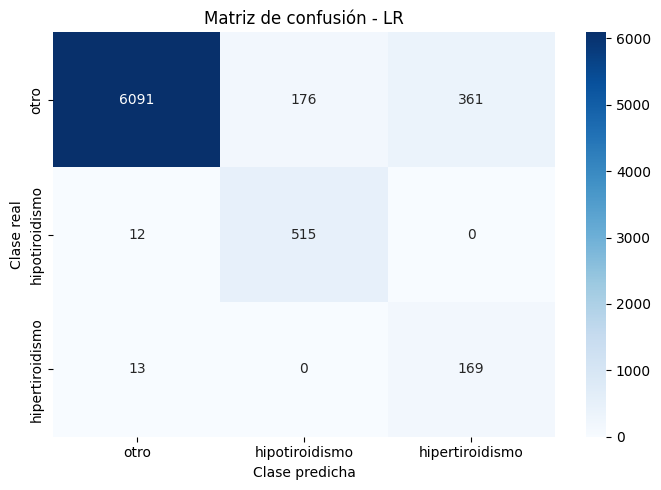

In [8]:
modelo_lr_cv = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    )),
])

metricas_lr_cv = evaluar_modelo_cv(
    "LR", modelo_lr_cv, "Blues"
)


## KNN

Resultados de KNN
-----------------
Exactitud: 0.9392
Sensibilidad macro: 0.6703
Especificidad macro: 0.8203
Precisión macro: 0.8556
F1-Score macro: 0.7323


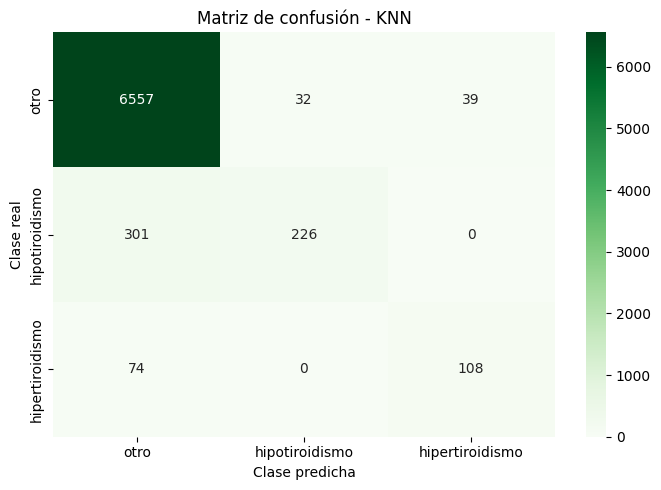

In [10]:
modelo_knn_cv = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", KNeighborsClassifier(n_neighbors=5)),
])

metricas_knn_cv = evaluar_modelo_cv(
    "KNN", modelo_knn_cv, "Greens"
)


## Árbol de decisión

Resultados de Árbol de Decisión
-------------------------------
Exactitud: 0.9832
Sensibilidad macro: 0.8919
Especificidad macro: 0.9646
Precisión macro: 0.9108
F1-Score macro: 0.9000


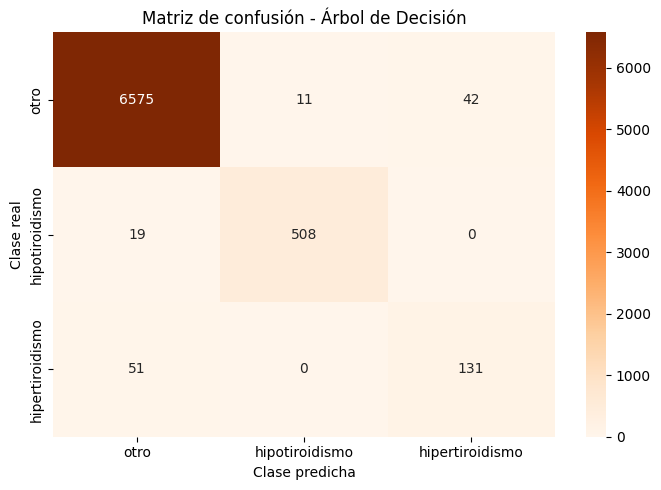

In [11]:
modelo_arbol_cv = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42,
    )),
])

metricas_arbol_cv = evaluar_modelo_cv(
    "Árbol de Decisión", modelo_arbol_cv, "Oranges"
)


## SVM

Resultados de SVM
-----------------
Exactitud: 0.9385
Sensibilidad macro: 0.9287
Especificidad macro: 0.9632
Precisión macro: 0.7146
F1-Score macro: 0.7886


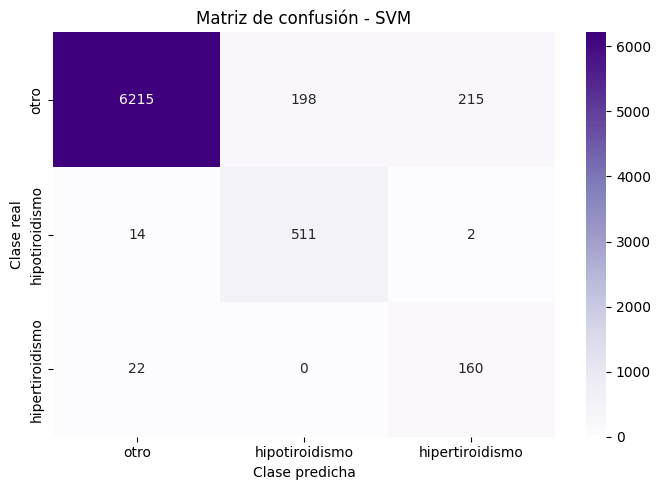

In [13]:
modelo_svm_cv = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
    )),
])

metricas_svm_cv = evaluar_modelo_cv(
    "SVM", modelo_svm_cv, "Purples"
)


## RF

Resultados de Random Forest
---------------------------
Exactitud: 0.9851
Sensibilidad macro: 0.8824
Especificidad macro: 0.9648
Precisión macro: 0.9421
F1-Score macro: 0.9073


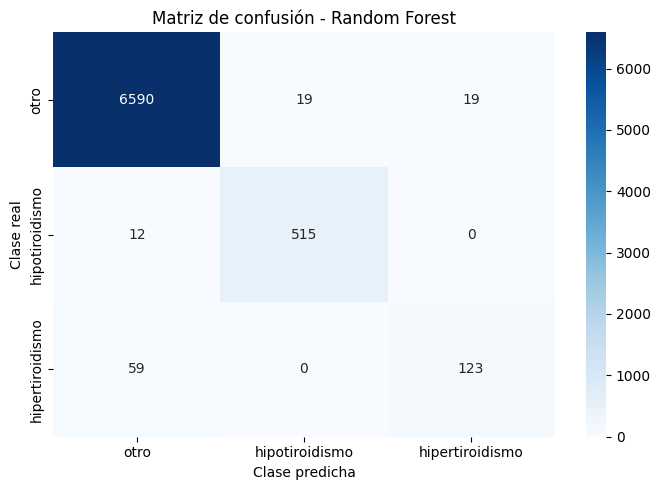

In [14]:
modelo_rf_cv = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
    )),
])

metricas_rf_cv = evaluar_modelo_cv(
    "Random Forest", modelo_rf_cv, "Blues"
)


## Comparación de los modelos

In [15]:
comparativa_cv = pd.DataFrame([
    metricas_lr_cv,
    metricas_knn_cv,
    metricas_arbol_cv,
    metricas_svm_cv,
    metricas_rf_cv,
]).set_index("Modelo")

display(comparativa_cv.round(4))


,Exactitud,Sensibilidad macro,Especificidad macro,Precisión macro,F1-Score macro
Modelo,,,,,
LR,0.9234,0.9414,0.9628,0.6871,0.7590
KNN,0.9392,0.6703,0.8203,0.8556,0.7323
Árbol de Decisión,0.9832,0.8919,0.9646,0.9108,0.9000
SVM,0.9385,0.9287,0.9632,0.7146,0.7886
Random Forest,0.9851,0.8824,0.9648,0.9421,0.9073
